# 02 — Confidence under shift: does the probability stay honest when conditions change?

> **Research question.** Can the model's own confidence / probability be trusted outside the
> conditions in which it was evaluated?

Second of three public notebooks (`01_signal_trust` → **`02_confidence_under_shift`** →
`03_when_not_to_help`). `01` asked whether the *signal* can be trusted; this notebook assumes a
QC-gated signal and asks whether the classifier's *probability* can be. That distinction is the
whole point:

> **prediction quality ≠ probability quality.** A model can keep most of its accuracy while its
> stated confidence stops meaning what it says. The confidence gate in `reborn.decision` consumes
> the probability, not the accuracy — so the probability is the quantity that has to be honest.

Each metric below is reported and interpreted **on its own scale**. Balanced accuracy, ECE, Brier
and NLL are not commensurate, and no statement of the form "X changes more than Y" across them is
made. ECE is a calibration-only, binning-dependent number; Brier and NLL are proper scoring rules
that reward calibration and sharpness together and are not pure calibration metrics.

## Scope box

| | |
|---|---|
| Dataset | Ninapro DB6 (public; local download, never committed — `data/README.md`) |
| Subjects | `s01`, `s02` — **two**; every cross-subject number here is a pilot observation |
| Sessions | 10 per subject (5 days × 2) |
| Montage | raw DB6 columns (0, 10), 2 channels; 5 Hudgins features per channel |
| Preprocessing | `experiments/configs/ninapro_db6_qc.json`; fingerprint printed below and stamped on every artifact |
| Window count | printed in §1 and recorded in `nb02_run_<fingerprint>.json` |
| Primary task | **binary** rest-vs-movement — Reborn's actual decision |
| Supporting task | 8-class grasp recognition, reported only as a **2-channel floor** |
| Models | LDA, logistic regression (both give probabilities that can be reasoned about) |
| Mode | **OFFLINE** — recorded data, no closed loop |
| Scale | **PILOT** — no population estimate is made |

Artifacts: `experiments/results/nb02_*_<fingerprint>.csv`; figures from `figures/render.py`.

## Setup

Needs scikit-learn (`pip install -e ".[ml]"`); run with `py -3.11`
(`docs/research/phase-b-plan.md` §10).

In [1]:
import csv
import json
import sys
import time
from pathlib import Path

import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from reborn.data.evaluation import evaluate_splits, pool_reliability_bins, summarize
from reborn.data.features import FEATURE_NAMES, feature_matrix, standardize
from reborn.data.loaders import NinaproDB6Loader
from reborn.data.pipeline import PreprocessConfig, build_window_set, load_window_set, save_window_set
from reborn.data.splits import (
    cross_session_splits,
    cross_subject_splits,
    random_window_split,
    within_session_splits,
)

RESULTS = REPO / "experiments" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

CONFIG = json.loads((REPO / "experiments" / "configs" / "ninapro_db6_qc.json").read_text())
QC_KWARGS = CONFIG["qc_kwargs"]
MONTAGE = tuple(CONFIG["channels"]["montage"])
PRE = CONFIG["preprocess"]

config = PreprocessConfig(
    target_sample_rate=PRE["target_sample_rate_hz"],
    bandpass_hz=tuple(PRE["bandpass_hz"]),
    notch_hz=PRE["notch_hz"],
    window_ms=PRE["window_ms"],
    stride_ms=PRE["stride_ms"],
    pure_windows=PRE["pure_windows"],
    qc_kwargs=QC_KWARGS,
)
STAMP = config.fingerprint()
print("config fingerprint:", STAMP)
print("features per channel:", FEATURE_NAMES)

config fingerprint: fed1e81a523e5d6e
features per channel: ('rms', 'mav', 'zcr', 'wl', 'ssc')


## 1. The window set

One pass: load → resample → filter → window → QC gate. Windows that fail deterministic QC never
reach the classifier — the runtime order, and the reason this notebook sits after `01`. The
`.npz` cache is keyed by the config fingerprint and shared with the other notebooks; delete it to
force a rebuild.

In [2]:
SUBJECTS = ["s01", "s02"]
SESSIONS = None            # None = every session

cache = REPO / "data" / "cache" / f"db6_{'_'.join(SUBJECTS)}_{STAMP}.npz"
loader = NinaproDB6Loader(REPO / "data" / "ninapro_db6", channels=MONTAGE)
if cache.exists():
    window_set = load_window_set(cache)
    print(f"loaded cache: {cache.name}")
else:
    started = time.time()
    window_set = build_window_set(loader.load(subjects=SUBJECTS, sessions=SESSIONS), config)
    save_window_set(window_set, cache, config)
    print(f"built and cached in {time.time() - started:.0f} s")

sessions = sorted(map(str, set(window_set.session_ids)))
print(f"\n{window_set.n_windows} windows, {window_set.n_channels} channels")
print(f"subjects: {sorted(map(str, set(window_set.subject_ids)))}")
print(f"sessions: {len(sessions)}  {sessions}")
print(f"QC rejected {window_set.qc.rejection_rate:.2%} of windows before this point")
print(f"repetition numbers available: {window_set.repetition_ids is not None}")

loaded cache: db6_s01_s02_fed1e81a523e5d6e.npz

259745 windows, 2 channels
subjects: ['s01', 's02']
sessions: 10  ['d01_t01', 'd01_t02', 'd02_t01', 'd02_t02', 'd03_t01', 'd03_t02', 'd04_t01', 'd04_t02', 'd05_t01', 'd05_t02']
QC rejected 0.40% of windows before this point
repetition numbers available: True


## 2. The task, and the honest reduction

Reborn's decision is binary — assist flexion, or do not. DB6 labels seven grasps plus rest. The
**binary task is derived as rest vs. any movement**, the closest honest mapping onto an elbow
orthosis, and is the primary task throughout. The **8-class task is kept as a floor**: two
electrodes cannot separate seven hand grasps, so any multi-class number here is a lower bound
that must never be compared with 14-channel literature results. It is reported so that the
reduction is visible rather than assumed.

Class balance matters for reading every number: if rest is a quarter of windows, a model that
always predicts "movement" already scores 75% accuracy. Balanced accuracy is therefore the
discrimination metric.

In [3]:
X_raw, feature_names = feature_matrix(window_set)
y_multi = window_set.labels
y_binary = window_set.binary_labels()

print(f"feature matrix: {X_raw.shape}")
print(f"columns: {feature_names}\n")
for name, y in (("binary (rest vs movement) — PRIMARY", y_binary), ("multi-class — 2-channel floor", y_multi)):
    labels, counts = np.unique(y, return_counts=True)
    shares = "  ".join(f"{lab}:{n / len(y):.1%}" for lab, n in zip(labels, counts))
    print(f"{name:<36}{len(labels)} classes   {shares}")
    print(f"{'':<36}majority-class accuracy = {counts.max() / len(y):.1%}")

feature matrix: (259745, 10)
columns: ['rms_ch0', 'rms_ch1', 'mav_ch0', 'mav_ch1', 'zcr_ch0', 'zcr_ch1', 'wl_ch0', 'wl_ch1', 'ssc_ch0', 'ssc_ch1']

binary (rest vs movement) — PRIMARY 2 classes   0:24.5%  1:75.5%
                                    majority-class accuracy = 75.5%
multi-class — 2-channel floor       8 classes   0:24.5%  1:11.4%  3:10.7%  4:11.0%  6:10.5%  9:11.0%  10:10.1%  11:10.7%
                                    majority-class accuracy = 24.5%


## 3. Models

LDA and logistic regression, both CPU-only and both producing probabilities that can be reasoned
about. Two things the wrapper gets right, and which are easy to get wrong:

- **Standardisation is fitted on training rows only** (`standardize`). Scaling with statistics
  pooled over train and test would leak the per-session amplitude shift into the model and
  flatter every cross-session number.
- **Confidence is the probability of the predicted class** — what `ConfidenceGate` consumes at
  runtime. The full probability matrix is also returned so the proper scoring rules can be
  computed on the true class. Nothing is rescaled to look better.

In [4]:
def make_fit_predict(estimator_factory):
    # (X_tr, y_tr, X_te) -> (pred, confidence, proba) with proba columns in np.unique(y_tr) order
    def fit_predict(X_train, y_train, X_test):
        X_train, X_test = standardize(X_train, X_test)
        model = estimator_factory().fit(X_train, y_train)
        proba = model.predict_proba(X_test)
        assert list(model.classes_) == list(np.unique(y_train))
        predictions = model.classes_[np.argmax(proba, axis=1)]
        confidence = np.max(proba, axis=1)
        return predictions, confidence, proba
    return fit_predict


MODELS = {
    "lda": make_fit_predict(LinearDiscriminantAnalysis),
    "logreg": make_fit_predict(lambda: LogisticRegression(max_iter=2000)),
}
print("models:", list(MODELS))

models: ['lda', 'logreg']


## 4. Protocols — and two design facts that govern how the spread must be read

| Protocol | Train | Test | What it isolates |
|---|---|---|---|
| within-session | earlier repetitions of session *k* | later repetitions of session *k* | ceiling |
| cross-session | the subject's **first** session | each later session, one split each | change across sessions |
| cross-subject | the other subject | held-out subject | pilot observation (n = 2) |
| random-shuffle | shuffled windows | shuffled windows | **leaky control, not a result** |

**Within-session splitting is repetition-aware.** DB6 is block-designed — all repetitions of one
grasp, then the next — so a temporal cut through a session would put whole classes on one side
of the line. `within_session_splits` holds out the *later repetitions of every gesture* instead
(the Ninapro convention); the split metadata records `split_by = repetition`.

**Cross-session splits share their training set.** `cross_session_splits(n_train_sessions=1)`
trains on the subject's first session and tests on each of the nine later sessions. The
resulting 18 splits are therefore **2 training sets × 9 test sessions**, not 18 independent
training replications. The spread across them is *test-session* variability given one training
session per subject, and every summary, whisker and per-split figure below must be read that
way.

**On the random-shuffle control.** Windows overlap by 150 ms, so shuffling puts near-copies of
the same window on both sides. How much that inflates a score depends on model capacity; for LDA
on ten features it may show little gap. The row is a control on the protocol-plus-model pair and
is reported as such, whatever it shows.

In [5]:
protocols = {
    "within-session": within_session_splits(window_set),
    "cross-session": cross_session_splits(window_set, n_train_sessions=1),
    "cross-subject": cross_subject_splits(window_set),
    "random-shuffle": [random_window_split(window_set, seed=0)],
}
for name, splits in protocols.items():
    print(f"{name:<18}{len(splits):>3} splits")

ws_meta = protocols["within-session"][0].meta
print(f"\nwithin-session split_by = {ws_meta['split_by']!r}; train reps {ws_meta.get('train_repetitions')}, "
      f"test reps {ws_meta.get('test_repetitions')}")
train_sets = sorted({(sp.meta['subject'], tuple(sp.meta['train_sessions'])) for sp in protocols['cross-session']})
print(f"cross-session training sets: {train_sets}  ->  {len(train_sets)} distinct training sets for "
      f"{len(protocols['cross-session'])} splits")
print(f"cross-subject: {len(protocols['cross-subject'])} splits over {len(SUBJECTS)} subjects (leave-one-out = train on one)")

within-session     20 splits
cross-session      18 splits
cross-subject       2 splits
random-shuffle      1 splits

within-session split_by = 'repetition'; train reps [1, 2, 3, 4, 5, 6, 7, 8], test reps [9, 10, 11, 12]
cross-session training sets: [(np.str_('s01'), (np.str_('d01_t01'),)), (np.str_('s02'), (np.str_('d01_t01'),))]  ->  2 distinct training sets for 18 splits
cross-subject: 2 splits over 2 subjects (leave-one-out = train on one)


## 5. Run every {task} × {model} combination

In [6]:
COMBOS = [(task, model) for task in ("binary", "multi") for model in MODELS]
labels_for = {"binary": y_binary, "multi": y_multi}

results_by_combo = {}
started = time.time()
for task, model_name in COMBOS:
    y = labels_for[task]
    combo_results = []
    for name, splits in protocols.items():
        combo_results.extend(evaluate_splits(X_raw, y, splits, MODELS[model_name], protocol=name))
    results_by_combo[(task, model_name)] = combo_results
    print(f"{task:<7}{model_name:<8}{len(combo_results):>3} splits evaluated")
print(f"\n({time.time() - started:.0f} s)")

binary lda      41 splits evaluated


binary logreg   41 splits evaluated


multi  lda      41 splits evaluated


multi  logreg   41 splits evaluated

(71 s)


## 6. Discrimination by protocol — balanced accuracy

Mean over splits with the min–max spread. Remember the design fact from §4: for cross-session
the spread is over test sessions that share a training session.

In [7]:
def subset(combo, protocol):
    return [r for r in results_by_combo[combo] if r.protocol == protocol]


summary_rows = []
for combo in COMBOS:
    for name in protocols:
        rows = subset(combo, name)
        if rows:
            summary_rows.append({"task": combo[0], "model": combo[1], "protocol": name, **summarize(rows)})


def table(field, fmt="{:.3f}", combos=COMBOS):
    header = f"{'protocol':<16}" + "".join(f"{t + '/' + m:>22}" for t, m in combos)
    print(header)
    print("-" * len(header))
    for name in protocols:
        line = f"{name:<16}"
        for combo in combos:
            rows = subset(combo, name)
            if not rows:
                line += f"{'-':>22}"
                continue
            s = summarize(rows)
            line += f"{fmt.format(s[field + '_mean']):>10} [{fmt.format(s[field + '_min'])}–{fmt.format(s[field + '_max'])}]"
        print(line)


print("balanced accuracy — mean [min–max] over splits\n")
table("balanced_accuracy")

balanced accuracy — mean [min–max] over splits

protocol                    binary/lda         binary/logreg             multi/lda          multi/logreg
--------------------------------------------------------------------------------------------------------
within-session       0.917 [0.627–0.974]     0.949 [0.641–0.993]     0.468 [0.415–0.627]     0.477 [0.425–0.641]
cross-session        0.896 [0.641–0.952]     0.929 [0.612–0.979]     0.359 [0.282–0.602]     0.376 [0.304–0.578]
cross-subject        0.912 [0.907–0.916]     0.945 [0.942–0.948]     0.273 [0.252–0.294]     0.284 [0.274–0.294]
random-shuffle       0.901 [0.901–0.901]     0.951 [0.951–0.951]     0.343 [0.343–0.343]     0.361 [0.361–0.361]


## 7. Probability quality by protocol — each metric on its own scale

Three quantities, three different things:

- **ECE** — weighted |confidence − accuracy| over 10 confidence bins. Calibration only; says
  nothing about sharpness; depends on the binning.
- **Brier** — a proper scoring rule. For the binary task it is the one-column form
  `mean((p − y)²)` on the movement probability (0.25 = uninformative). For the 8-class task it is
  the multiclass sum-form, on a *different scale* — the two task columns are not comparable.
- **NLL** — negative log-likelihood of the true class; a proper scoring rule, same definition for
  both tasks, unbounded above, and heavily penalising confident wrong calls.

Each table is read on its own. No ratio or difference across tables is computed or implied.

In [8]:
for field, title in (("ece", "ECE (10 bins)"), ("brier", "Brier — binary: one-column form; multi: sum-form (different scale)"),
                     ("nll", "NLL / log loss")):
    print(f"{title} — mean [min–max] over splits\n")
    table(field)
    print()

ECE (10 bins) — mean [min–max] over splits

protocol                    binary/lda         binary/logreg             multi/lda          multi/logreg
--------------------------------------------------------------------------------------------------------
within-session       0.016 [0.005–0.040]     0.012 [0.002–0.038]     0.065 [0.034–0.123]     0.030 [0.010–0.056]
cross-session        0.027 [0.005–0.187]     0.028 [0.004–0.218]     0.164 [0.036–0.284]     0.109 [0.023–0.184]
cross-subject        0.024 [0.016–0.033]     0.017 [0.016–0.018]     0.204 [0.121–0.286]     0.163 [0.115–0.211]
random-shuffle       0.011 [0.011–0.011]     0.007 [0.007–0.007]     0.024 [0.024–0.024]     0.015 [0.015–0.015]

Brier — binary: one-column form; multi: sum-form (different scale) — mean [min–max] over splits

protocol                    binary/lda         binary/logreg             multi/lda          multi/logreg
-------------------------------------------------------------------------------------------

## 8. Reliability diagrams as data

Per-bin confidence vs. accuracy, computed per split by the harness (`reliability_bins`) and
pooled exactly per protocol (`pool_reliability_bins`, count-weighted). The binary within-session
vs cross-session tables are printed; all combos are persisted for `figures/render.py`.

In [9]:
reliability_rows = {}
for combo in COMBOS:
    rows = []
    for name in protocols:
        pooled = pool_reliability_bins(r.reliability for r in subset(combo, name))
        rows.extend({"protocol": name, **b} for b in pooled)
    reliability_rows[combo] = rows

for model_name in MODELS:
    print(f"binary / {model_name}")
    print(f"{'bin':<12}{'within n':>10}{'conf':>7}{'acc':>7}    {'cross n':>9}{'conf':>7}{'acc':>7}")
    print("-" * 66)
    w = [b for b in reliability_rows[("binary", model_name)] if b["protocol"] == "within-session"]
    x = [b for b in reliability_rows[("binary", model_name)] if b["protocol"] == "cross-session"]
    for bw, bx in zip(w, x):
        if bw["n"] == 0 and bx["n"] == 0:
            continue
        fmt = lambda b: f"{b['n']:>10}{b['mean_confidence']:>7.2f}{b['accuracy']:>7.2f}" if b["n"] else f"{'-':>10}{'':>14}"
        print(f"({bw['bin_low']:.1f}, {bw['bin_high']:.1f}]{fmt(bw)}    {fmt(bx)[1:]}")
    print()

binary / lda
bin           within n   conf    acc      cross n   conf    acc
------------------------------------------------------------------
(0.5, 0.6]      2507   0.55   0.57        10225   0.55   0.56
(0.6, 0.7]      2909   0.65   0.68        11455   0.65   0.65
(0.7, 0.8]      3753   0.75   0.78        14318   0.75   0.74
(0.8, 0.9]      6723   0.86   0.88        23450   0.86   0.84
(0.9, 1.0]     70760   0.98   0.98       173106   0.98   0.97

binary / logreg
bin           within n   conf    acc      cross n   conf    acc
------------------------------------------------------------------
(0.5, 0.6]      1367   0.55   0.60         5156   0.55   0.54
(0.6, 0.7]      1548   0.65   0.69         5626   0.65   0.59
(0.7, 0.8]      2244   0.75   0.79         6674   0.75   0.67
(0.8, 0.9]      4040   0.86   0.88         9919   0.85   0.80
(0.9, 1.0]     77453   0.99   0.99       205179   0.99   0.98



## 9. Per-split variability under cross-session

One row per elapsed-session offset. Each row holds **two splits — one per subject — that share
nothing except the offset**, and within a subject every split shares the same training session.
Read the shape, not a trend: the question is whether change across sessions is uniform or is
carried by particular sessions.

In [10]:
for model_name in MODELS:
    combo = ("binary", model_name)
    by_elapsed = {}
    for r in subset(combo, "cross-session"):
        by_elapsed.setdefault(r.meta.get("sessions_elapsed"), []).append(r)
    print(f"binary / {model_name} — cross-session, per elapsed-session offset (2 splits per row, one per subject)")
    print(f"{'elapsed':>8}{'splits':>7}{'bal.acc':>16}{'ECE':>16}{'NLL':>16}")
    print("-" * 63)
    for elapsed in sorted(k for k in by_elapsed if k is not None):
        rows = by_elapsed[elapsed]
        cell = lambda f: "  ".join(f"{getattr(r, f):.3f}" for r in sorted(rows, key=lambda r: r.meta["subject"]))
        print(f"{elapsed:>8}{len(rows):>7}{cell('balanced_accuracy'):>16}{cell('ece'):>16}{cell('nll'):>16}")
    worst = min(subset(combo, "cross-session"), key=lambda r: r.balanced_accuracy)
    print(f"  lowest balanced accuracy: {worst.split}  bal.acc {worst.balanced_accuracy:.3f}  ECE {worst.ece:.3f}  NLL {worst.nll:.3f}\n")
print("(columns list s01 then s02)")

binary / lda — cross-session, per elapsed-session offset (2 splits per row, one per subject)
 elapsed splits         bal.acc             ECE             NLL
---------------------------------------------------------------
       1      2    0.878  0.934    0.007  0.025    0.212  0.221
       2      2    0.924  0.925    0.019  0.027    0.182  0.271
       3      2    0.870  0.641    0.006  0.187    0.214  0.764
       4      2    0.919  0.945    0.023  0.013    0.206  0.226
       5      2    0.904  0.932    0.010  0.028    0.212  0.248
       6      2    0.922  0.929    0.019  0.027    0.193  0.228
       7      2    0.821  0.952    0.015  0.014    0.330  0.168
       8      2    0.895  0.923    0.005  0.032    0.257  0.264
       9      2    0.875  0.943    0.009  0.022    0.218  0.200
  lowest balanced accuracy: cross-session/s02/d02_t02  bal.acc 0.641  ECE 0.187  NLL 0.764

binary / logreg — cross-session, per elapsed-session offset (2 splits per row, one per subject)
 elapsed splits

## 10. Artifacts

In [11]:
def write_csv(path, rows):
    if not rows:
        print(f"skipped {path.name}: nothing to write")
        return
    fields = list(dict.fromkeys(key for row in rows for key in row))
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)
    print(f"wrote {path.relative_to(REPO).as_posix()}  ({len(rows)} rows)")


for (task, model_name), results in results_by_combo.items():
    write_csv(RESULTS / f"nb02_splits_{task}_{model_name}_{STAMP}.csv", [r.as_row() for r in results])
    write_csv(RESULTS / f"nb02_reliability_{task}_{model_name}_{STAMP}.csv", reliability_rows[(task, model_name)])
write_csv(RESULTS / f"nb02_summary_{STAMP}.csv", summary_rows)

(RESULTS / f"nb02_run_{STAMP}.json").write_text(
    json.dumps(
        {
            "notebook": "02_confidence_under_shift",
            "config_fingerprint": STAMP,
            "dataset": "ninapro_db6",
            "mode": "offline",
            "scale": "pilot",
            "subjects": SUBJECTS,
            "sessions": SESSIONS or "all",
            "n_windows": int(window_set.n_windows),
            "qc_rejection_rate": window_set.qc.rejection_rate,
            "montage_raw_columns": list(MONTAGE),
            "features": list(FEATURE_NAMES),
            "primary_task": "binary",
            "combos": [f"{t}_{m}" for t, m in COMBOS],
            "protocol_split_counts": {k: len(v) for k, v in protocols.items()},
            "within_session_split_by": ws_meta["split_by"],
            "cross_session_n_train_sessions": 1,
            "cross_session_distinct_training_sets": len(train_sets),
            "metrics": ["accuracy", "balanced_accuracy", "ece", "brier", "nll", "false_assist_rate"],
            "note_false_assist_rate": "ungated classifier quantity; gated analysis is in 03_when_not_to_help",
        },
        indent=2,
    )
)
print(f"wrote experiments/results/nb02_run_{STAMP}.json")

wrote experiments/results/nb02_splits_binary_lda_fed1e81a523e5d6e.csv  (41 rows)
wrote experiments/results/nb02_reliability_binary_lda_fed1e81a523e5d6e.csv  (40 rows)
wrote experiments/results/nb02_splits_binary_logreg_fed1e81a523e5d6e.csv  (41 rows)
wrote experiments/results/nb02_reliability_binary_logreg_fed1e81a523e5d6e.csv  (40 rows)
wrote experiments/results/nb02_splits_multi_lda_fed1e81a523e5d6e.csv  (41 rows)
wrote experiments/results/nb02_reliability_multi_lda_fed1e81a523e5d6e.csv  (40 rows)
wrote experiments/results/nb02_splits_multi_logreg_fed1e81a523e5d6e.csv  (41 rows)
wrote experiments/results/nb02_reliability_multi_logreg_fed1e81a523e5d6e.csv  (40 rows)
wrote experiments/results/nb02_summary_fed1e81a523e5d6e.csv  (16 rows)
wrote experiments/results/nb02_run_fed1e81a523e5d6e.json


## 11. Figures

Rendered from the CSVs in §10 by `figures/render.py`.

figures/F2_1_reliability_fed1e81a523e5d6e.png


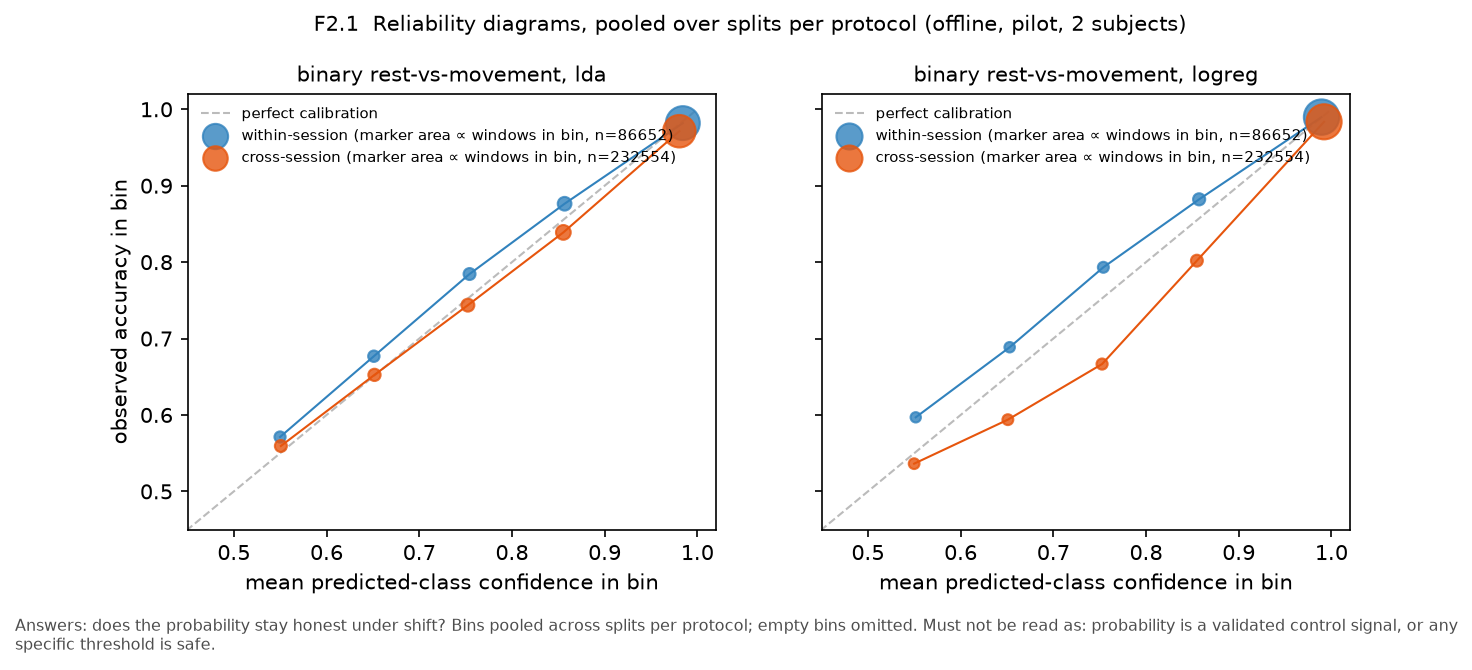

figures/F2_2_metrics_by_protocol_fed1e81a523e5d6e.png


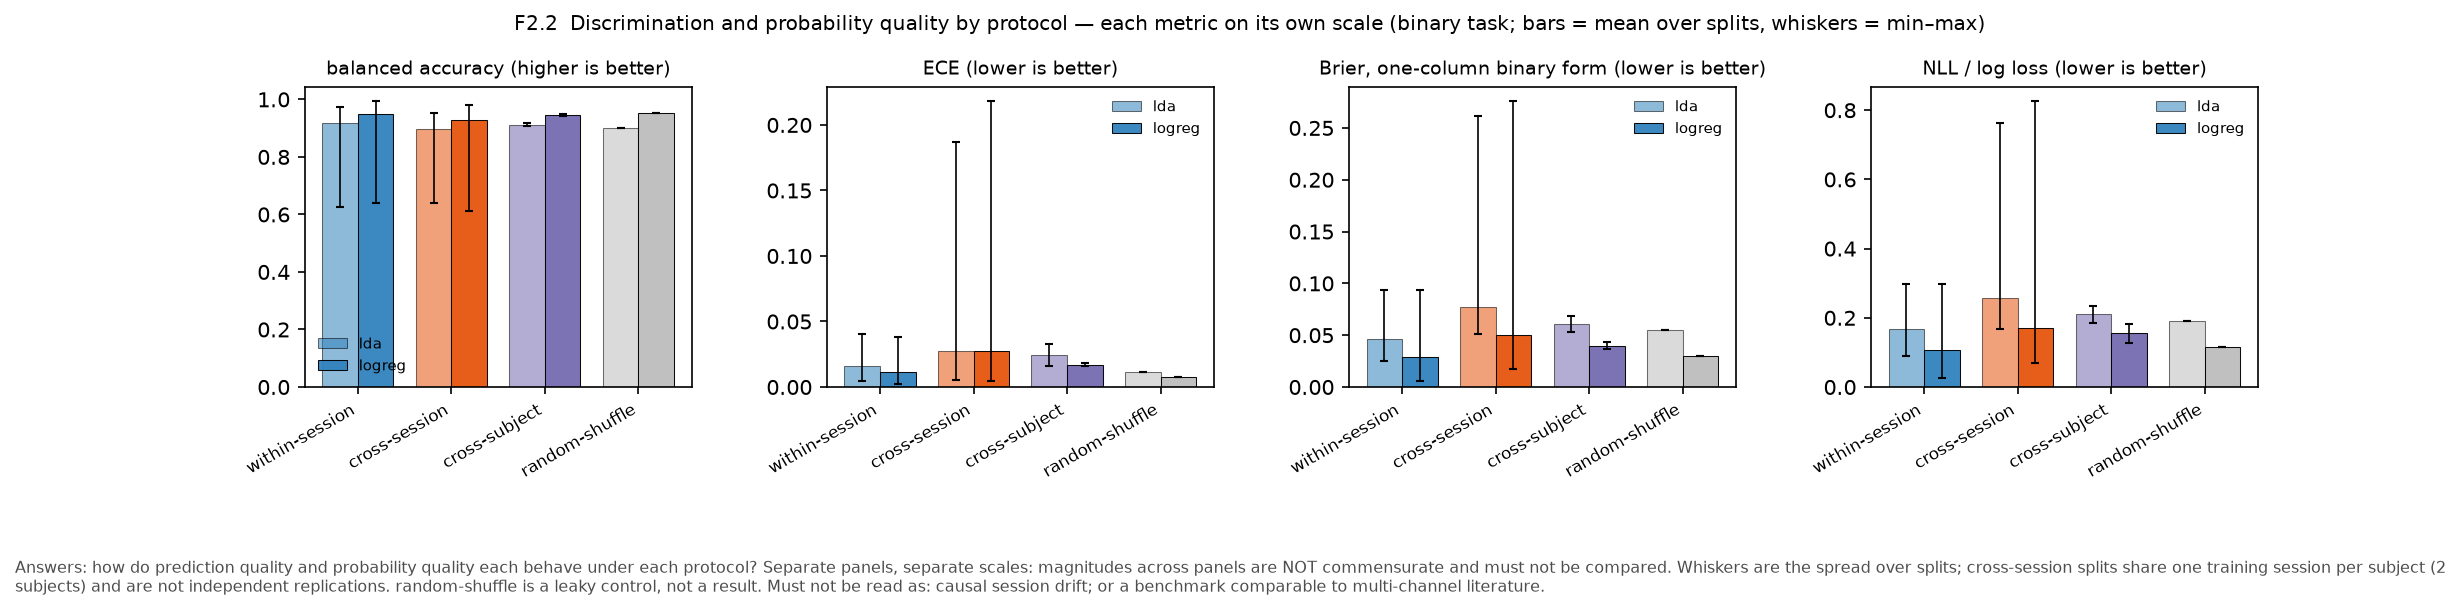

figures/F2_3_per_split_fed1e81a523e5d6e.png


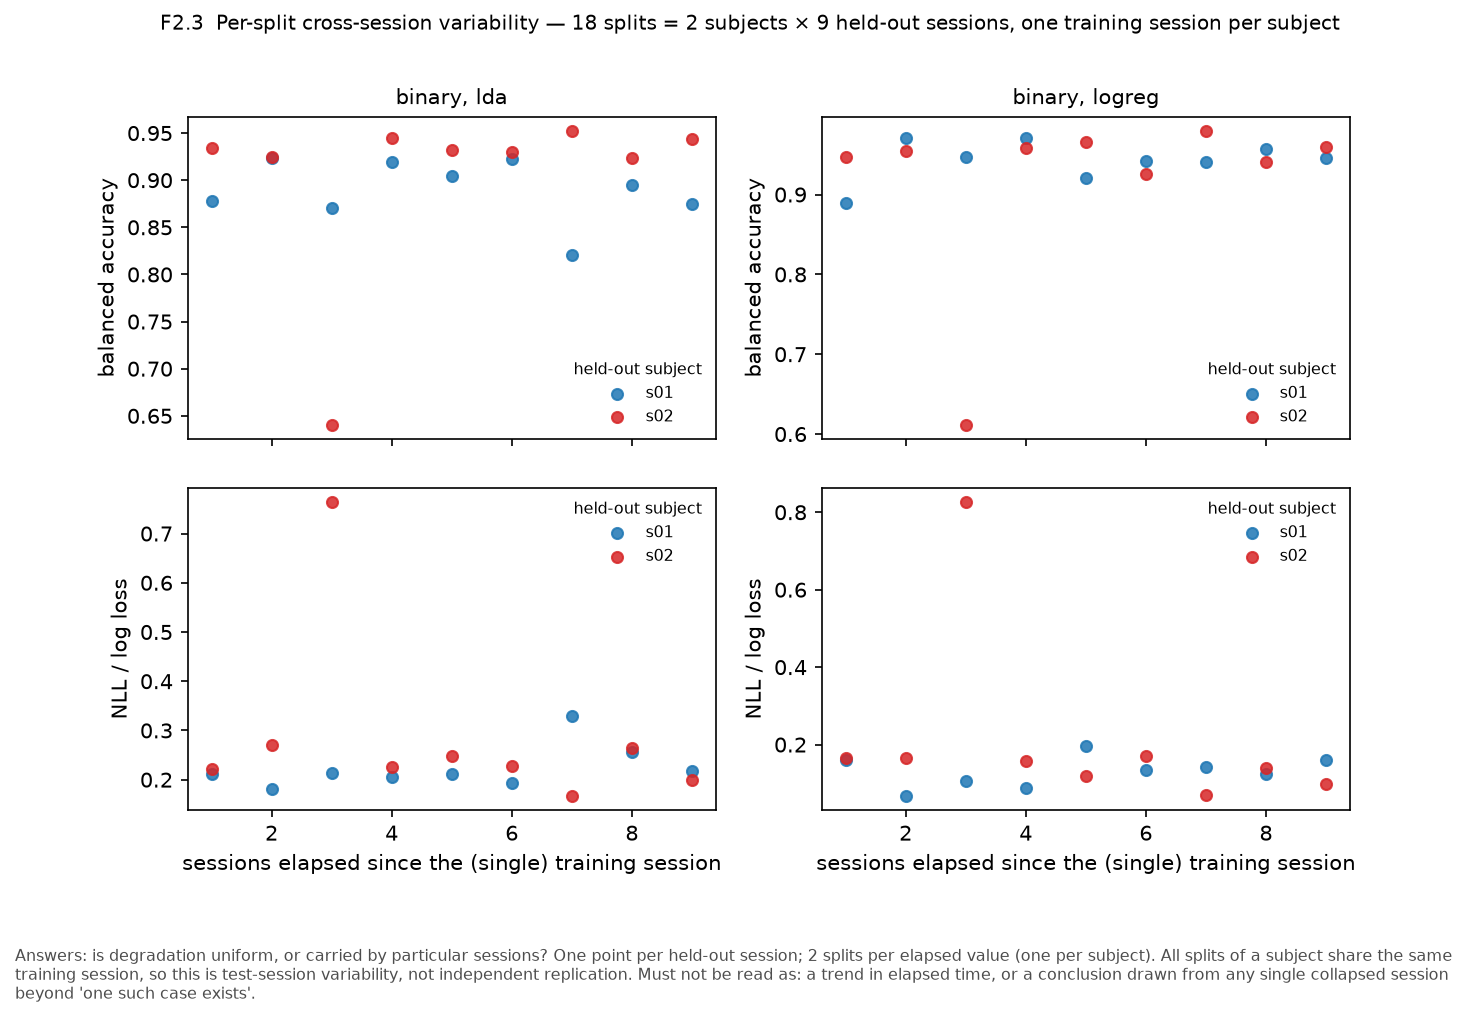

In [12]:
from IPython.display import Image, display

from figures.render import render_nb2

for path in render_nb2(RESULTS, REPO / "figures", STAMP):
    print(path.relative_to(REPO).as_posix())
    display(Image(filename=str(path)))

## 12. Reading, limitations, and what this notebook must not be used to claim

The printed tables are authoritative; this section describes the committed run, metric by metric.

### Discrimination (balanced accuracy)

- On the **binary** task both models keep most of their within-session balanced accuracy under
  cross-session evaluation; the multi-class floor loses much more balanced accuracy, as expected of a 2-channel
  montage asked to separate seven grasps. For the decision Reborn actually makes, the discrimination
  loss across sessions is modest in this pilot.
- The **cross-session spread is not uniform**: most held-out sessions sit near the within-session
  level and one (`s02/d02_t02`) sits far below it. With one training session per subject this is
  an observation about which sessions differ from the training session, not a trend in elapsed
  time.
- **Cross-subject** on the binary task is in the same range as cross-session. With two subjects
  this is a pilot observation and nothing more.
- The **random-shuffle control** shows no inflation for these models, consistent with their low
  capacity; it must be re-run before any higher-capacity model is trusted.

### Calibration (ECE)

- Binary ECE is small within-session and larger on average cross-session for both models, and its spread
  across held-out sessions is wide, with the collapsed session carrying the largest value.

### Proper scoring rules (Brier, NLL)

- Binary Brier and NLL are both higher (worse) cross-session than within-session, and both have
  their maximum on the same collapsed session. NLL's maximum is far above its median, which is
  what a proper scoring rule does with confident wrong calls.

### What is *not* concluded

- No causal "session drift" claim. The protocol contrasts show that a model fit on one session
  scores differently on other sessions of the same subject; they do not isolate *why*, and the
  companion signal-trust notebook found that gesture composition alone can move a monitor's
  behaviour.
- No cross-metric comparison. Nothing above says calibration changed "more" or "faster" than
  accuracy; the metrics are on different scales and no same-scale analysis exists here.
- No claim that the probability is a validated control signal, and no threshold on it is
  recommended — that is `03_when_not_to_help`'s question, and it is asked there as a trade-off.
- Nothing here is the formal full-cohort result; this is two subjects, offline.

### Limitations

Two subjects; two channels; one training session per subject under cross-session; 10-bin ECE;
no recalibration step applied (a simple recalibration baseline is a deferred follow-up, not part
of this pass).

### Where this leads

The ungated `false_assist_rate` column in the split CSVs is the classifier's own false-movement
rate with **no** confidence threshold applied — it carries no safety meaning. What a gate on the
probability buys and costs is `03_when_not_to_help`.